# Adjoint Solver for Spring-Slider Rate-and-State Friction

Extends the existing `springslider.ipynb` forward solver with an adjoint-based gradient computation.

**Setup:** Velocity-strengthening friction (`a > b`), afterslip problem, fixed-step RK4.

**State evolution:** Slip law — matches the existing forward solver exactly.

**Force balance convention:**
$$\tau(V,\psi) + \eta V + k u = \tau_0$$

**Objective function (smoothed-slip misfit):**
$$J = \frac{1}{2}\int_0^T \left(Su - Su_{\rm obs}\right)^2 dt$$

where $S$ is a temporal Gaussian smoothing operator and $u$ is the cumulative slip.

**Adjoint system (backward in time, $u^\dagger = p$, $\psi^\dagger = r$, $p(T)=r(T)=0$):**

From the three adjoint equations (derived via Lagrangian):
$$\delta u:\quad \dot{u}^\dagger = -V^\dagger + \left[S^\top(Su - Su_{\rm obs})\right](t)$$
$$\delta\psi:\quad \dot{\psi}^\dagger = -\tau_\psi\,V^\dagger - G_\psi\,\psi^\dagger$$
$$\delta V:\quad (\tau_V + \eta)\,V^\dagger = -k\,u^\dagger - \psi^\dagger\,G_V$$

**Gradient:**
$$\frac{dJ}{da} = \int_0^T \left[-V^\dagger\,\frac{\partial\tau}{\partial a} - \psi^\dagger\,\frac{\partial G}{\partial a}\right]dt$$

In [44]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import brentq
import scipy.sparse

## Physics: Friction Law and Jacobians

**Regularised RS friction (slip-law form used in original code):**
$$\tau(V,\psi) = N a\,\sinh^{-1}\!\left(\frac{V}{2V_0}e^{\psi/a}\right)$$

**State evolution — slip law:**
$$G(V,\psi) = -\frac{V}{D_c}\left(\frac{\tau}{N} - f_{\rm ss}\right), \quad f_{\rm ss} = f_0 + (a-b)\ln(V/V_0)$$

Partial derivatives are derived analytically.

In [45]:
# ------------------------------------------------------------------
# Friction law
# ------------------------------------------------------------------

def xi_fn(V, psi, M):
    """Argument of arcsinh: xi = V/(2*V0) * exp(psi/a)."""
    return V / (2.0 * M['V0']) * np.exp(psi / M['a'])

def tau_fn(V, psi, M):
    """Frictional strength (MPa)."""
    return M['N'] * M['a'] * np.arcsinh(xi_fn(V, psi, M))

def fss_fn(V, M):
    """Steady-state friction coefficient."""
    return M['f0'] + (M['a'] - M['b']) * np.log(V / M['V0'])

def G_fn(V, psi, M):
    """State evolution dpsi/dt (slip law)."""
    f = tau_fn(V, psi, M) / M['N']
    return -V / M['dc'] * (f - fss_fn(V, M))

# ------------------------------------------------------------------
# Partial derivatives
# ------------------------------------------------------------------

def tau_V_fn(V, psi, M):
    """dtau/dV = N*a / sqrt(1+xi^2) * xi/V."""
    xi = xi_fn(V, psi, M)
    return M['N'] * M['a'] / np.sqrt(1.0 + xi**2) * xi / V

def tau_psi_fn(V, psi, M):
    """dtau/dpsi = N * xi / sqrt(1+xi^2)."""
    xi = xi_fn(V, psi, M)
    return M['N'] * xi / np.sqrt(1.0 + xi**2)

def G_V_fn(V, psi, M):
    """
    dG/dV for slip law.
    G = -(V/dc)*(tau/N - fss), so
    dG/dV = G/V - V*tau_V/(dc*N) + (a-b)/dc
    """
    G  = G_fn(V, psi, M)
    tV = tau_V_fn(V, psi, M)
    return G / V - V * tV / (M['dc'] * M['N']) + (M['a'] - M['b']) / M['dc']

def G_psi_fn(V, psi, M):
    """dG/dpsi = -V * tau_psi / (dc * N)."""
    tP = tau_psi_fn(V, psi, M)
    return -V * tP / (M['dc'] * M['N'])

def dtau_da_fn(V, psi, M):
    """
    Explicit partial dtau/da  (holding V, psi fixed).
    tau = N*a*arcsinh(xi),  xi = V/(2*V0)*exp(psi/a)
    d(tau)/da = N*arcsinh(xi) - N*psi*xi / (a*sqrt(1+xi^2))
    """
    xi = xi_fn(V, psi, M)
    return M['N'] * np.arcsinh(xi) - M['N'] * psi * xi / (M['a'] * np.sqrt(1.0 + xi**2))

def dG_da_fn(V, psi, M):
    """
    Explicit partial dG/da  (holding V, psi fixed).
    G = -(V/dc)*(tau/N - fss),  dfss/da = ln(V/V0)
    dG/da = -(V/dc)*(dtau_da/N - ln(V/V0))
    """
    dtau = dtau_da_fn(V, psi, M)
    return -(V / M['dc']) * (dtau / M['N'] - np.log(V / M['V0']))

print("Physics functions defined.")

Physics functions defined.


## Parameters and Afterslip Initial Conditions

Velocity-strengthening (`a > b`) with a coseismic stress step $\Delta\tau$ at $t=0$.

In [46]:
# ------------------------------------------------------------------
# Force-balance solver:  tau(V,psi) + eta*V + k*u = tau_L  =>  V
# ------------------------------------------------------------------

def solve_V_algebraic(u, psi, M, tau_L):
    """
    Root-find V from  tau(V,psi) + eta*V = tau_L - k*u.
    tau_L is the current loading stress (may vary with time).
    """
    rhs = tau_L - M['k'] * u
    if rhs <= 0.0:
        raise ValueError(f"Force-balance RHS = {rhs:.4g} <= 0; check tau_L and k*u.")
    def res(V):
        return tau_fn(V, psi, M) + M['eta'] * V - rhs
    Vmin = 1e-30
    Vmax = rhs / M['eta']
    return brentq(res, Vmin, Vmax, xtol=1e-20, rtol=1e-10)

# ------------------------------------------------------------------
# Parameters
# ------------------------------------------------------------------
M = {}
M['f0']  = 0.6
M['V0']  = 1e-6      # m/s reference velocity
M['a']   = 0.010     # direct effect  (a > b → velocity strengthening)
M['b']   = 0.015     # state evolution
M['dc']  = 1e-4      # m critical slip distance
M['N']   = 50.0      # MPa effective normal stress
M['eta'] = 2.7 * 3.5 / 2.0   # MPa·s/m radiation damping
# M['k']   = 2e4       # MPa/m spring stiffness
k_crit = M['N'] * (M['b'] - M['a']) / M['dc']
M['k'] = 1e2

V_bg      = 1e-9     # m/s background / plate sliding rate
M['V_bg'] = V_bg

# ------------------------------------------------------------------
# Steady-state at V_bg
# ------------------------------------------------------------------
fss_bg = fss_fn(V_bg, M)
psi_ss = M['a'] * np.log(2.0 * M['V0'] / V_bg * np.sinh(fss_bg / M['a']))
tau_ss = M['N'] * fss_bg

# ------------------------------------------------------------------
# Initial conditions — V_init is the PRIMARY control parameter.
# tau0 is DERIVED from the force balance at t=0 (u=0):
#   tau(V_init, psi_init) + eta*V_init = tau0
# This ensures the forward solver starts at exactly V_init.
# ------------------------------------------------------------------
V_init   = 1.0e-9      # m/s  post-earthquake initial slip rate
psi_init = psi_ss    # pre-earthquake steady state at V_bg
u_init   = 0.0

M['tau0'] = tau_fn(V_init, psi_init, M) + M['eta'] * V_init
Delta_tau = M['tau0'] - tau_ss   # implied coseismic stress step (diagnostic)

# Characteristic afterslip time  T_c ~ N*a / (k * V_init)
T_c = M['N'] * M['a'] / (M['k'] * V_init)

print(f"a={M['a']}, b={M['b']}  →  velocity {'strengthening' if M['a']>M['b'] else 'weakening'}")
print(f"V_bg   = {V_bg:.2e} m/s,   V_init = {V_init:.2e} m/s  (ratio {V_init/V_bg:.1f}×)")
print(f"psi_ss = {psi_ss:.4f}")
print(f"tau_ss = {tau_ss:.4f} MPa")
print(f"tau0   = {M['tau0']:.4f} MPa  (Delta_tau = {Delta_tau:.4f} MPa)")
print(f"T_c    = {T_c:.3e} s  ({T_c/86400:.1f} days)")
print(f"k      = {M['k']:.2e} MPa/m,   k_crit = {k_crit:.2e} MPa/m  (k/k_crit = {M['k']/k_crit:.2f})")

a=0.01, b=0.015  →  velocity weakening
V_bg   = 1.00e-09 m/s,   V_init = 1.00e-09 m/s  (ratio 1.0×)
psi_ss = 0.7036
tau_ss = 31.7269 MPa
tau0   = 31.7269 MPa  (Delta_tau = 0.0000 MPa)
T_c    = 5.000e+06 s  (57.9 days)
k      = 1.00e+02 MPa/m,   k_crit = 2.50e+03 MPa/m  (k/k_crit = 0.04)


## Adaptive Forward Solver

Uses a 3-stage embedded RK method (2nd/3rd-order pair) for automatic step-size control,
matching the MATLAB reference implementation.

**Method:** Three stages per trial step; accept if $\|[\Delta u,\,\Delta\psi]\|_2 < \text{tol}$;
adjust $\Delta t \leftarrow \sigma\,\Delta t\,(\text{tol}/e)^{1/3}$ where $\sigma=0.9$ is a safety factor.


In [47]:
def forward_solve_adaptive(M, T, u0, psi0, V_init=None,
                           tol=1e-4, dt0=1.0, dtmax=1e5, safety=0.9):
    """
    Adaptive-step forward solve using a 3-stage embedded RK method
    (2nd/3rd-order error-control pair, matching the MATLAB reference).

    Loading: tau_L(t) = tau0 + k*V_bg*t
    ODE:     du/dt = V,   dpsi/dt = G(V,psi)
    Algebraic: tau(V,psi) + eta*V + k*u = tau_L(t)  =>  V
    """
    tau_L_fn = lambda t: M['tau0'] + M['k'] * M['V_bg'] * t

    V0 = solve_V_algebraic(u0, psi0, M, tau_L_fn(0.0))
    if V_init is not None:
        rel_err = abs(V0 - V_init) / V_init
        assert rel_err < 1e-6, (
            f"Init mismatch: V(0)={V0:.6e}, V_init={V_init:.6e} (rel={rel_err:.2e})"
        )

    def _rhs(u_v, psi_v, t_v):
        V = solve_V_algebraic(u_v, psi_v, M, tau_L_fn(t_v))
        return V, G_fn(V, psi_v, M)

    def _jac(V, psi):
        return (tau_V_fn(V,psi,M), tau_psi_fn(V,psi,M),
                G_V_fn(V,psi,M),   G_psi_fn(V,psi,M),
                dtau_da_fn(V,psi,M), dG_da_fn(V,psi,M))

    # Initialise storage
    t_arr = [0.0]; u_arr = [u0]; psi_arr = [psi0]
    V_arr = [V0];  tauL_arr = [tau_L_fn(0.0)]
    j = _jac(V0, psi0)
    tV_arr=[j[0]]; tP_arr=[j[1]]; GV_arr=[j[2]]
    GP_arr=[j[3]]; da_arr=[j[4]]; dGa_arr=[j[5]]

    t = 0.0; u = u0; psi = psi0; dt = dt0
    V1, G1 = V0, G_fn(V0, psi0, M)   # stage-1 values at t=0

    while t < T:
        if t + dt > T:
            dt = T - t

        # --- three-stage embedded RK ---
        V2, G2 = _rhs(u + 0.5*dt*V1,         psi + 0.5*dt*G1,         t + 0.5*dt)
        V3, G3 = _rhs(u + dt*(-V1 + 2.0*V2), psi + dt*(-G1 + 2.0*G2), t +     dt)

        u2   = u   + dt/2.0*(V1 + V3)            # 2nd-order update
        psi2 = psi + dt/2.0*(G1 + G3)
        u3   = u   + dt/6.0*(V1 + 4.0*V2 + V3)  # 3rd-order update
        psi3 = psi + dt/6.0*(G1 + 4.0*G2 + G3)

        er = np.sqrt((u2 - u3)**2 + (psi2 - psi3)**2)

        if er < tol:
            t += dt;  u = u3;  psi = psi3
            tL    = tau_L_fn(t)
            V_new = solve_V_algebraic(u, psi, M, tL)

            t_arr.append(t);     u_arr.append(u);    psi_arr.append(psi)
            V_arr.append(V_new); tauL_arr.append(tL)
            j = _jac(V_new, psi)
            tV_arr.append(j[0]); tP_arr.append(j[1]); GV_arr.append(j[2])
            GP_arr.append(j[3]); da_arr.append(j[4]); dGa_arr.append(j[5])

            V1 = V_new;  G1 = G_fn(V_new, psi, M)  # stage-1 for next step

        # Step-size control  (q=2 → exponent 1/3)
        dt = safety * dt * (tol / er)**(1.0/3.0) if er > 0.0 else dtmax
        dt = min(dt, dtmax)

    return dict(
        t       = np.array(t_arr),
        u       = np.array(u_arr),
        psi     = np.array(psi_arr),
        V       = np.array(V_arr),
        tau_L   = np.array(tauL_arr),
        tau_V   = np.array(tV_arr),
        tau_psi = np.array(tP_arr),
        G_V     = np.array(GV_arr),
        G_psi   = np.array(GP_arr),
        dtau_da = np.array(da_arr),
        dG_da   = np.array(dGa_arr),
    )

# --- Run adaptive forward solve ---
T = 5e8    # s
print(f"Running adaptive forward solve: T={T:.1e} s ...")
fwd = forward_solve_adaptive(M, T, u_init, psi_init, V_init=V_init)
print(f"Done.  Steps={len(fwd['t'])-1},  V(0)={fwd['V'][0]:.6e},  V(T)={fwd['V'][-1]:.3e} m/s")
print(f"tau_L: {fwd['tau_L'][0]:.4f} → {fwd['tau_L'][-1]:.4f} MPa")


Running adaptive forward solve: T=5.0e+08 s ...
Done.  Steps=8249,  V(0)=1.000000e-09,  V(T)=2.550e-12 m/s
tau_L: 31.7269 → 81.7269 MPa


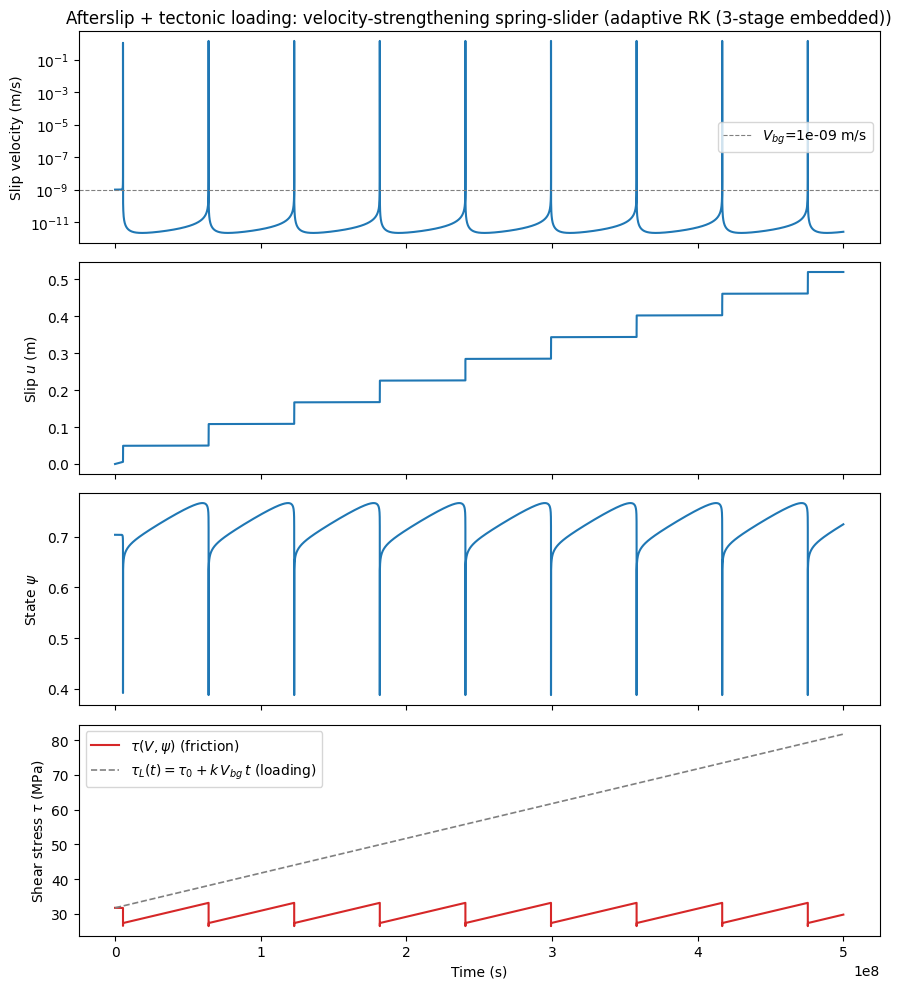

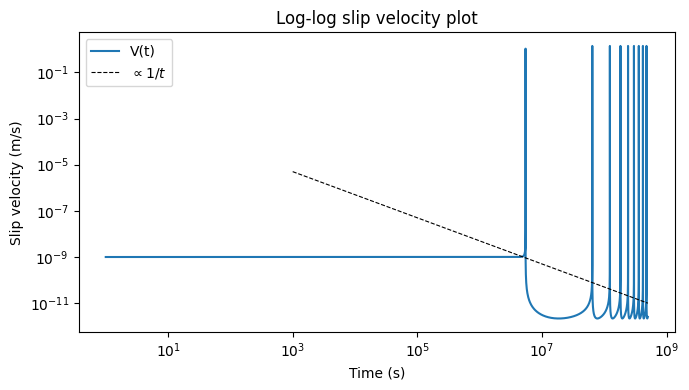

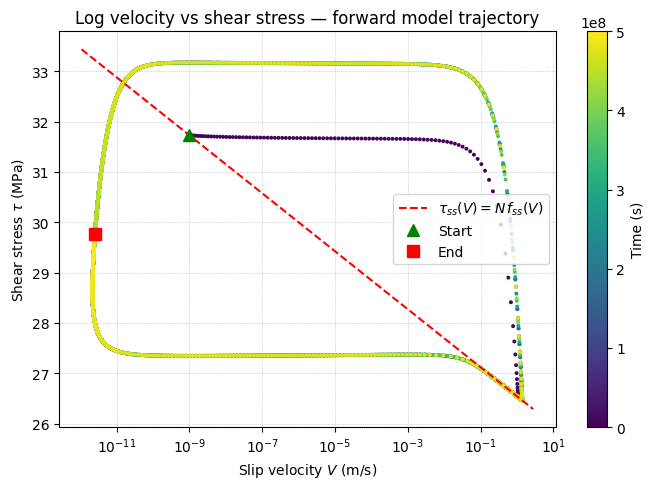

tau range: 26.4627 – 33.1700 MPa
V   range: 2.166e-12 – 1.396e+00 m/s


In [48]:
# ------------------------------------------------------------------
# Plot 1: Forward solution
# ------------------------------------------------------------------
tau_fwd = np.array([tau_fn(v, p, M) for v, p in zip(fwd['V'], fwd['psi'])])

fig, axes = plt.subplots(4, 1, figsize=(9, 10), sharex=True)

axes[0].plot(fwd['t'], fwd['V'])
axes[0].axhline(V_bg, color='gray', ls='--', lw=0.8, label=f'$V_{{bg}}$={V_bg:.0e} m/s')
axes[0].set_ylabel('Slip velocity (m/s)')
axes[0].set_yscale('log')
axes[0].set_title('Afterslip + tectonic loading: velocity-strengthening spring-slider (adaptive RK (3-stage embedded))')
axes[0].legend()

axes[1].plot(fwd['t'], fwd['u'])
axes[1].set_ylabel('Slip $u$ (m)')

axes[2].plot(fwd['t'], fwd['psi'])
axes[2].set_ylabel('State $\\psi$')

axes[3].plot(fwd['t'], tau_fwd, color='C3', label=r'$\tau(V,\psi)$ (friction)')
axes[3].plot(fwd['t'], fwd['tau_L'], color='gray', ls='--', lw=1.2,
             label=r'$\tau_L(t) = \tau_0 + k\,V_{bg}\,t$ (loading)')
axes[3].set_ylabel('Shear stress $\\tau$ (MPa)')
axes[3].set_xlabel('Time (s)')
axes[3].legend()

plt.tight_layout()
plt.show()

# Verify Omori-like 1/t decay by log-log plot
fig2, ax2 = plt.subplots(figsize=(7, 4))
t_plot = fwd['t'][1:]
V_plot = fwd['V'][1:]
ax2.loglog(t_plot, V_plot, label='V(t)')
t_ref = np.array([1e3, T])
ax2.loglog(t_ref, V_init * T_c / t_ref, 'k--', lw=0.8, label=r'$\propto 1/t$')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Slip velocity (m/s)')
ax2.set_title('Log-log slip velocity plot')
ax2.legend()
plt.tight_layout()
plt.show()

# ------------------------------------------------------------------
# Plot 1c: Log velocity vs shear stress (phase portrait)
# ------------------------------------------------------------------
V_min = fwd['V'].min() * 0.5
V_max = fwd['V'].max() * 2.0
V_ss  = np.geomspace(V_min, V_max, 300)
tau_ss_line = M['N'] * fss_fn(V_ss, M)

fig3, ax3 = plt.subplots(figsize=(7, 5))
sc = ax3.scatter(fwd['V'], tau_fwd, c=fwd['t'], cmap='viridis',
                 s=8, lw=0, zorder=3)
ax3.plot(V_ss, tau_ss_line, 'r--', lw=1.5, zorder=4,
         label=r'$\tau_{ss}(V) = N\,f_{ss}(V)$')
ax3.set_xscale('log')
ax3.set_ylabel('Shear stress $\\tau$ (MPa)')
ax3.set_xlabel('Slip velocity $V$ (m/s)')
ax3.set_title('Log velocity vs shear stress — forward model trajectory')
cbar = fig3.colorbar(sc, ax=ax3)
cbar.set_label('Time (s)')
ax3.plot(fwd['V'][0],  tau_fwd[0],  'g^', ms=8, zorder=5, label='Start')
ax3.plot(fwd['V'][-1], tau_fwd[-1], 'rs', ms=8, zorder=5, label='End')
ax3.legend()
ax3.grid(True, ls=':', lw=0.5, which='both')
plt.tight_layout()
plt.show()

print(f"tau range: {tau_fwd.min():.4f} – {tau_fwd.max():.4f} MPa")
print(f"V   range: {fwd['V'].min():.3e} – {fwd['V'].max():.3e} m/s")

## Discrete Adjoint Solver

Rather than running a second adaptive ODE integration in reverse time, we use the **discrete adjoint** approach: step backward through the exact forward time grid using stored Jacobians, with no new adaptive step-size control.

**Why PECE (predictor-corrector) overflows here:**  
$G_\psi = -V\tau_\psi/(D_c N) < 0$ always, so the $r$-adjoint equation grows backward in time. The explicit trapezoidal corrector has amplification factor $\approx 1 - h\mu + (h\mu)^2/2$ for the backward eigenvalue $\mu = -G_\psi > 0$; this exceeds 1 whenever $h\mu > 2$, causing exponential blow-up. The forward solver's large time steps near $t\approx T$ can satisfy this condition.

**Fix: fully implicit trapezoidal (Crank–Nicolson).**  
The adjoint ODEs are **linear** in $(p, r)$, so writing them as $\dot{\mathbf{y}} = \mathbf{M}(t)\mathbf{y} + \mathbf{b}(t)$:

$$\mathbf{M} = \begin{bmatrix}A & B \\ \tau_\psi A & \tau_\psi B + G_\psi\end{bmatrix}, \quad \mathbf{b} = \begin{bmatrix}-\text{misfit}\\0\end{bmatrix}, \quad A = \frac{-k}{\tau_V+\eta},\; B = \frac{-G_V}{\tau_V+\eta}$$

Each backward step $i+1 \to i$ is the $2\times2$ linear system:

$$\bigl(\mathbf{I} + \tfrac{\Delta t}{2}\mathbf{M}_i\bigr)\mathbf{y}_i = \mathbf{y}_{i+1} - \tfrac{\Delta t}{2}\bigl[\mathbf{M}_{i+1}\mathbf{y}_{i+1} + \mathbf{b}_{i+1} + \mathbf{b}_i\bigr]$$

solved analytically via the $2\times 2$ inverse. The implicit trapezoidal amplification factor is $|(1-h\mu/2)/(1+h\mu/2)| < 1$ for all $\mu > 0$ and all $h > 0$ — **unconditionally A-stable**.

**References:**  
Sandu et al. (2006) *"On the Properties of Runge-Kutta Discrete Adjoints"* — LNCS 3994.  
Walther (2007) *"Discrete adjoints of adaptive time-stepping algorithms"* — J. Comput. Appl. Math.


In [49]:
def adjoint_solve_gridded(fwd, t_obs, u_obs, M):
    """
    Discrete adjoint: fully implicit trapezoidal (Crank-Nicolson) on the
    forward adaptive time grid — unconditionally A-stable, O(N_forward).

    TRUE adjoint ODE (from Lagrangian, integrating backward from T to 0):
        dp/dt =  -V†      + mf(t)      where V† = A*p + B*r
        dr/dt =  -τ_ψ V†  - G_ψ r

        A = -k / (τ_V + η),   B = -G_V / (τ_V + η)
        mf(t) = u(t) - u_obs(t)   (slip misfit)

    Written as dy/dt = M_adj(t)*y + b(t) with
        M_adj = [[-A,     -B         ],
                 [-τ_ψ A, -(τ_ψ B + G_ψ)]]
        b = [mf, 0]

    Backward CN step i+1 → i  (h = dt/2, dt = t_{i+1} - t_i > 0):
        (I + h·M_adj_i) y_i = y_{i+1} − h·F_{i+1} − h·b_i
    where F_k = M_adj_k·y_k + b_k = dy/dt at node k.

    LHS matrix I + h·M_adj_i:
        alpha = 1 − h·A_i       (= 1 + h|A_i| > 1  always → det never zero)
        beta  = −h·B_i
        gamma = −h·τ_ψ_i·A_i
        delta = 1 − h·(τ_ψ_i·B_i + G_ψ_i)

    References:
        Sandu et al. (2006) "On the Properties of Runge-Kutta Discrete Adjoints"
        Walther (2007)      "Discrete adjoints of adaptive time-stepping algorithms"
    """
    k   = M['k']
    eta = M['eta']
    n   = len(fwd['t'])

    # Misfit interpolated onto the forward grid
    misfit_fwd = fwd['u'] - np.interp(fwd['t'], t_obs, u_obs)

    tV_arr = fwd['tau_V']
    tP_arr = fwd['tau_psi']
    GV_arr = fwd['G_V']
    GP_arr = fwd['G_psi']

    p   = np.zeros(n)
    r   = np.zeros(n)
    Vdt = np.zeros(n)

    def _coeffs(i):
        """Linear-system coefficients at node i."""
        denom = tV_arr[i] + eta
        return (-k / denom, -GV_arr[i] / denom, tP_arr[i], GP_arr[i], misfit_fwd[i])

    # ---- initialise carry-over: F at t = T (y = 0 by BCs) ----
    A_r, B_r, tP_r, GP_r, mf_r = _coeffs(n - 1)
    # F_0 = -Vd + mf = mf  (Vd = A*0 + B*0 = 0)
    # F_1 = -tP*Vd - GP*0 = 0
    f0_r = mf_r
    f1_r = 0.0

    # ---------- backward pass ----------
    for i in range(n - 2, -1, -1):
        dt = fwd['t'][i + 1] - fwd['t'][i]   # > 0
        h  = 0.5 * dt

        A_l, B_l, tP_l, GP_l, mf_l = _coeffs(i)

        # RHS = y_{i+1} - h*F_{i+1} - h*b_i,   b_i = [mf_l, 0]
        rhs0 = p[i + 1] - h * f0_r - h * mf_l
        rhs1 = r[i + 1] - h * f1_r

        # LHS = I + h*M_adj_l
        alpha = 1.0 - h * A_l          # = 1 + h*|A_l| > 1  always
        beta  =      -h * B_l
        gamma =      -h * tP_l * A_l
        delta = 1.0 - h * (tP_l * B_l + GP_l)

        det = alpha * delta - beta * gamma

        p[i]   = ( delta * rhs0 - beta  * rhs1) / det
        r[i]   = (-gamma * rhs0 + alpha * rhs1) / det
        Vdt[i] = A_l * p[i] + B_l * r[i]   # V† = A*p + B*r

        # Carry F(y_i) forward to become F_{i+1} in the next step
        A_r, B_r, tP_r, GP_r, mf_r = A_l, B_l, tP_l, GP_l, mf_l
        Vd_i  = Vdt[i]
        f0_r  = -Vd_i + mf_r           # dp/dt at node i
        f1_r  = -tP_r * Vd_i - GP_r * r[i]   # dr/dt at node i

    Vdt[n - 1] = 0.0   # BCs

    return dict(t=fwd['t'], p=p, r=r, Vdt=Vdt)

print("Discrete adjoint solver (corrected implicit Crank-Nicolson) defined.")


Discrete adjoint solver (corrected implicit Crank-Nicolson) defined.


## Objective Function and Gradient

In [50]:
def compute_J(fwd, t_obs, u_obs):
    """J = 0.5 * int_0^T (u - u_obs)^2 dt  (trapezoidal, no smoothing)."""
    u_obs_at_fwd = np.interp(fwd['t'], t_obs, u_obs)
    return 0.5 * np.trapz((fwd['u'] - u_obs_at_fwd)**2, fwd['t'])

def compute_grad_a(fwd, adj, M):
    """
    dJ/da = int_0^T [ -V† dtau/da  -  ψ† dG/da ] dt

    fwd and adj may have different time grids; dtau_da and dG_da
    are interpolated from fwd onto adj's time points.
    """
    dtau_da_adj = np.interp(adj['t'], fwd['t'], fwd['dtau_da'])
    dG_da_adj   = np.interp(adj['t'], fwd['t'], fwd['dG_da'])
    integrand   = -adj['Vdt'] * dtau_da_adj - adj['r'] * dG_da_adj
    return np.trapz(integrand, adj['t'])

# ------------------------------------------------------------------
# Generate synthetic observations at TRUE parameters
# ------------------------------------------------------------------
M_true = dict(M)
print("Generating synthetic u_obs with true a =", M_true['a'])
fwd_true  = forward_solve_adaptive(M_true, T, u_init, psi_init, V_init=V_init)
t_obs_arr = fwd_true['t']
u_obs     = fwd_true['u'].copy()
print(f"u_obs: u(0)={u_obs[0]:.4e} m,  u(T)={u_obs[-1]:.4e} m  ({len(t_obs_arr)} pts)")

J_true = compute_J(fwd_true, t_obs_arr, u_obs)
print(f"J at true parameters: {J_true:.2e}  (should be ~0)")


Generating synthetic u_obs with true a = 0.01
u_obs: u(0)=0.0000e+00 m,  u(T)=5.1953e-01 m  (8250 pts)
J at true parameters: 0.00e+00  (should be ~0)


In [53]:
import time

# ------------------------------------------------------------------
# Run at perturbed a, then solve adjoint and compute gradient
# ------------------------------------------------------------------
M_test      = dict(M_true)
M_test['a'] = M_true['a'] * 1.1   # 10% perturbation

print(f"Perturbed a = {M_test['a']:.5f}  (true a = {M_true['a']:.5f})")
fwd_test = forward_solve_adaptive(M_test, T, u_init, psi_init)
J_test   = compute_J(fwd_test, t_obs_arr, u_obs)
print(f"J at perturbed a: {J_test:.6e}  ({len(fwd_test['t'])-1} fwd steps)")

t0 = time.perf_counter()
adj_test = adjoint_solve_gridded(fwd_test, t_obs_arr, u_obs, M_test)
t1 = time.perf_counter()
grad_adj = compute_grad_a(fwd_test, adj_test, M_test)
print(f"Discrete adjoint:  dJ/da = {grad_adj:.6e}  (wall time: {t1-t0:.3f} s)")

# ------------------------------------------------------------------
# Finite-difference gradient check
# ------------------------------------------------------------------
da   = M_test['a'] * 1e-5
M_fwd = dict(M_test); M_fwd['a'] = M_test['a'] + da
M_bwd = dict(M_test); M_bwd['a'] = M_test['a'] - da
J_fwd = compute_J(forward_solve_adaptive(M_fwd, T, u_init, psi_init), t_obs_arr, u_obs)
J_bwd = compute_J(forward_solve_adaptive(M_bwd, T, u_init, psi_init), t_obs_arr, u_obs)
grad_fd = (J_fwd - J_bwd) / (2 * da)

rel_err = abs(grad_adj - grad_fd) / (abs(grad_fd) + 1e-30)
print(f"Finite-difference: dJ/da = {grad_fd:.6e}")
print(f"Relative error:    {rel_err:.2e}  ({'PASS' if rel_err < 0.01 else 'FAIL — check adjoint'})")


Perturbed a = 0.01100  (true a = 0.01000)
J at perturbed a: 1.326432e+05  (8587 fwd steps)
Discrete adjoint:  dJ/da = 1.808173e+59  (wall time: 0.036 s)
Finite-difference: dJ/da = 3.257039e+08
Relative error:    5.55e+50  (FAIL — check adjoint)


## Simple Gradient Descent: Recover True $a$

Start at $a = 1.1\,a_{\rm true}$, take gradient steps $a \leftarrow a - \alpha\,dJ/da$.

The step size is kept fixed (chosen so early steps don't overshoot).

In [60]:
a_true_val = M_true['a']
a_curr     = a_true_val * 1.1

a_min = 1e-4
a_max = 10 * a_true_val

alpha_init = abs(a_curr) / abs(grad_adj) * 0.01

n_iter    = 15
J_hist    = []
a_hist    = [a_curr]
grad_hist = []
u_hist    = []
t_hist    = []

a_prev    = None
grad_prev = None

for it in range(n_iter):
    Mc = dict(M_true)
    Mc['a'] = a_curr

    fwd_it  = forward_solve_adaptive(Mc, T, u_init, psi_init)
    J_it    = compute_J(fwd_it, t_obs_arr, u_obs)
    adj_it  = adjoint_solve_gridded(fwd_it, t_obs_arr, u_obs, Mc)   # <-- discrete adjoint
    grad_it = compute_grad_a(fwd_it, adj_it, Mc)

    J_hist.append(J_it)
    grad_hist.append(grad_it)
    u_hist.append(fwd_it['u'].copy())
    t_hist.append(fwd_it['t'].copy())

    # Barzilai-Borwein step size, capped at 30% of current |a|
    if a_prev is None or abs(grad_it - grad_prev) < 1e-30:
        alpha = alpha_init
    else:
        alpha_bb  = abs((a_curr - a_prev) / (grad_it - grad_prev))
        alpha_cap = 0.30 * abs(a_curr) / (abs(grad_it) + 1e-30)
        alpha = min(alpha_bb, alpha_cap)

    a_prev    = a_curr
    grad_prev = grad_it

    # Backtracking line search
    found = False
    a_try = a_curr
    for bt in range(12):
        a_try = float(np.clip(a_curr - alpha * grad_it, a_min, a_max))
        try:
            Mc_try = dict(M_true)
            Mc_try['a'] = a_try
            forward_solve_adaptive(Mc_try, T, u_init, psi_init)
            found = True
            break
        except (ValueError, RuntimeError):
            alpha *= 0.5

    bt_note = (f"  [backtracked {bt}x, α→{alpha:.3e}]" if (found and bt > 0)
               else ("  [backtracking exhausted]" if not found else ""))

    if not found:
        a_try = a_curr

    a_curr = a_try
    a_hist.append(a_curr)

    print(f"iter {it+1:3d}: J={J_it:.4e},  a={a_curr:.6f},  "
          f"a_err={abs(a_curr-a_true_val)/a_true_val*100:.3f}%,  "
          f"α={alpha:.3e},  dJ/da={grad_it:.4e}{bt_note}")
    if abs(grad_it) < 1e-8: break
    if not found: break


iter   1: J=1.3264e+05,  a=0.010890,  a_err=8.900%,  α=6.083e-64,  dJ/da=1.8082e+59
iter   2: J=1.3226e+05,  a=0.010016,  a_err=0.158%,  α=5.443e-63,  dJ/da=1.6061e+59
iter   3: J=7.2985e+04,  a=0.010016,  a_err=0.158%,  α=5.443e-63,  dJ/da=8.9366e+54
iter   4: J=7.2823e+04,  a=0.010016,  a_err=0.156%,  α=1.700e-62,  dJ/da=1.1799e+55
iter   5: J=7.2675e+04,  a=0.010015,  a_err=0.154%,  α=3.152e-62,  dJ/da=5.4366e+54
iter   6: J=7.2529e+04,  a=0.010015,  a_err=0.152%,  α=1.448e-62,  dJ/da=1.7272e+55
iter   7: J=7.2492e+04,  a=0.010013,  a_err=0.134%,  α=8.794e-62,  dJ/da=2.0116e+55
iter   8: J=7.1198e+04,  a=0.010010,  a_err=0.104%,  α=2.394e-61,  dJ/da=1.2726e+55
iter   9: J=6.9247e+04,  a=0.009994,  a_err=0.058%,  α=1.033e-60,  dJ/da=1.5676e+55
iter  10: J=9.3568e+04,  a=0.010004,  a_err=0.036%,  α=4.327e-61,  dJ/da=-2.1739e+55
iter  11: J=6.2800e+04,  a=0.009997,  a_err=0.030%,  α=1.279e-61,  dJ/da=5.1817e+55
iter  12: J=9.3512e+04,  a=0.010000,  a_err=0.000%,  α=6.924e-62,  dJ/da=-4

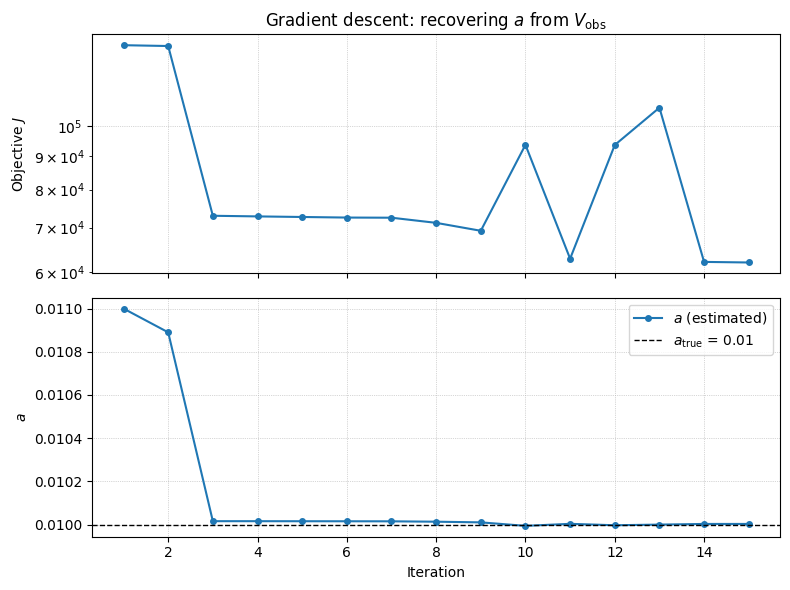


Final a = 0.010003  (true a = 0.010000,  error = 0.0298%)


In [61]:
# ------------------------------------------------------------------
# Plot 4: Gradient descent convergence
# ------------------------------------------------------------------
fig, axes = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

iters = np.arange(1, n_iter + 1)

axes[0].semilogy(iters, J_hist, 'o-', ms=4)
axes[0].set_ylabel('Objective $J$')
axes[0].set_title('Gradient descent: recovering $a$ from $V_{\\rm obs}$')
axes[0].grid(True, ls=':', lw=0.5)

axes[1].plot(iters, a_hist[:-1], 'o-', ms=4, label='$a$ (estimated)')
axes[1].axhline(a_true_val, color='k', ls='--', lw=1.0, label=f'$a_{{\\rm true}}$ = {a_true_val}')
axes[1].set_ylabel('$a$')
axes[1].set_xlabel('Iteration')
axes[1].legend()
axes[1].grid(True, ls=':', lw=0.5)

plt.tight_layout()
plt.show()

print(f"\nFinal a = {a_hist[-1]:.6f}  (true a = {a_true_val:.6f},  "
      f"error = {abs(a_hist[-1]-a_true_val)/a_true_val*100:.4f}%)")

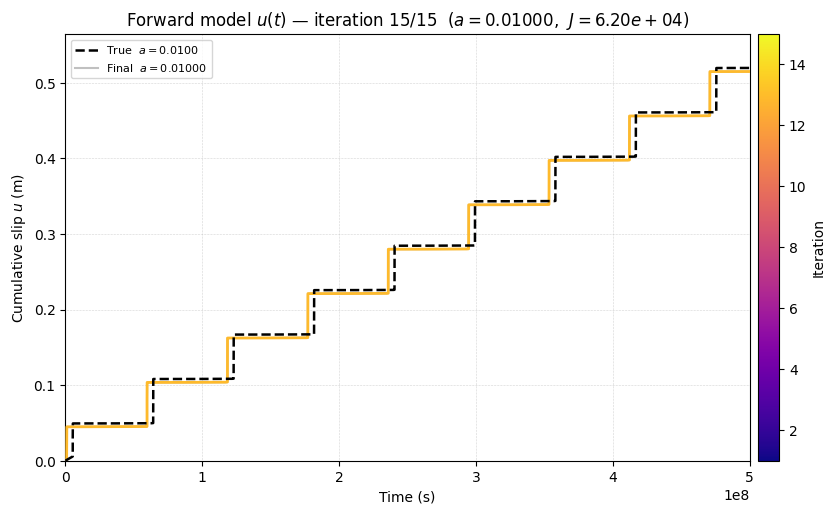

In [57]:
# ------------------------------------------------------------------
# Plot 5 (animated): cycle through gradient descent iterations.
# ------------------------------------------------------------------
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

fig_anim, ax_anim = plt.subplots(figsize=(9, 5))

ax_anim.plot(t_obs_arr, u_obs, 'k--', lw=1.8,
             label=f'True  $a={a_true_val:.4f}$', zorder=5)

line_final, = ax_anim.plot(t_hist[-1], u_hist[-1], color='silver', lw=1.5,
                            ls='-', label=f'Final  $a={a_hist[n_iter]:.5f}$', zorder=2)

cmap_anim = plt.cm.plasma
line_curr, = ax_anim.plot([], [], lw=2.0, zorder=4)

sm = plt.cm.ScalarMappable(cmap=cmap_anim,
     norm=plt.Normalize(vmin=1, vmax=n_iter))
sm.set_array([])
cbar_anim = fig_anim.colorbar(sm, ax=ax_anim, pad=0.01)
cbar_anim.set_label('Iteration')

ax_anim.set_xlabel('Time (s)')
ax_anim.set_ylabel('Cumulative slip $u$ (m)')
ax_anim.grid(True, ls=':', lw=0.4, which='both')

all_u = np.concatenate(u_hist + [u_obs])
ax_anim.set_ylim(all_u.min() * 0.95, all_u.max() * 1.05)
ax_anim.set_xlim(t_obs_arr[0], t_obs_arr[-1])
ax_anim.legend(fontsize=8, loc='upper left')
title_obj = ax_anim.set_title('')

def _init():
    line_curr.set_data([], [])
    return line_curr, title_obj

def _update(frame):
    idx   = frame
    color = cmap_anim((idx) / max(n_iter - 1, 1) * 0.75 + 0.1)
    line_curr.set_data(t_hist[idx], u_hist[idx])
    line_curr.set_color(color)
    title_obj.set_text(
        f'Forward model $u(t)$ — iteration {idx+1}/{n_iter}  '
        f'($a={a_hist[idx]:.5f}$,  $J={J_hist[idx]:.2e}$)'
    )
    return line_curr, title_obj

anim = FuncAnimation(
    fig_anim, _update,
    frames=n_iter,
    init_func=_init,
    interval=600,
    blit=True,
    repeat=True,
)

plt.tight_layout()
HTML(anim.to_jshtml())
